# 03 · Bank-line analysis

Bank position on 870 transects at every pass, 2015–2025.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config
M = config.METRICS_DIR
def load(name):
    p = M / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"


In [2]:
from src.banks.bank_position import load_positions
pos = load_positions()
print(pos.shape, "valid share", round(pos.bank_pos_m.notna().mean(), 3))
pos.groupby(pos.date.dt.year)["bank_pos_m"].apply(lambda v: v.notna().mean()).rename("valid share by year")

(236041, 14) valid share 0.872


date
2015    0.878301
2016    0.888016
2017    0.859118
2018    0.862104
2019    0.843185
2020    0.872525
2021    0.931803
2022    0.911637
2023    0.894604
2024    0.833175
2025    0.817656
Name: valid share by year, dtype: float64

In [3]:
w = pos.pivot_table(index="transect_id", columns="date", values="bank_pos_m")
first = w.T.iloc[:20].median(); last = w.T.iloc[-20:].median()
(last - first).rename("net_retreat_m").sort_values(ascending=False).head(10).to_frame()

,net_retreat_m
transect_id,
E-23700,1955.0
E-23500,1915.0
E-23900,1575.0
E-25900,1430.0
E-25700,1330.0
E-24100,1300.0
E-26100,1245.0
W-52300,1155.0
W-52100,1085.0


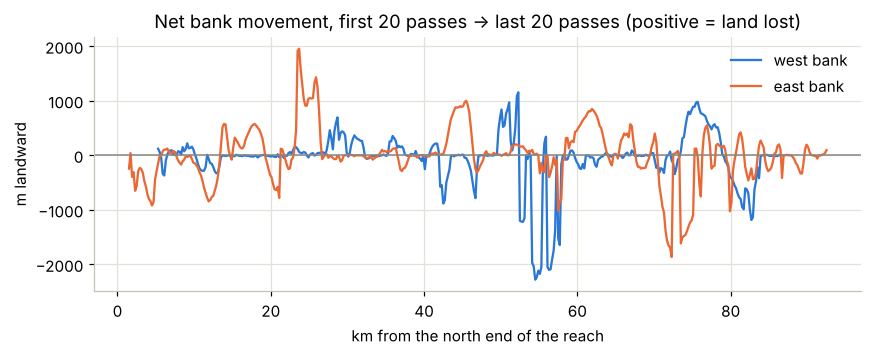

In [4]:
from src.banks.transects import load_transects
tr = load_transects().set_index("transect_id")
net2 = (last - first).rename("net").to_frame().join(tr[["bank", "chainage_m"]])
fig, ax = plt.subplots(figsize=(9, 3))
for b, c in (("W", C1), ("E", C2)):
    g = net2[net2.bank == b].sort_values("chainage_m")
    ax.plot(g.chainage_m / 1000, g.net, color=c, lw=1.5, label={"W": "west bank", "E": "east bank"}[b])
ax.axhline(0, color="#898781", lw=1); ax.set_xlabel("km from the north end of the reach"); ax.set_ylabel("m landward")
ax.set_title("Net bank movement, first 20 passes → last 20 passes (positive = land lost)"); ax.legend(frameon=False)
plt.show()

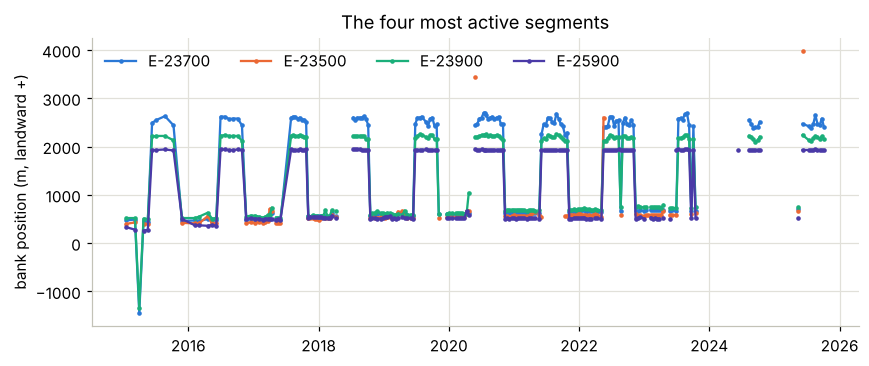

In [5]:
top = net2.net.sort_values(ascending=False).index[:4]
fig, ax = plt.subplots(figsize=(9, 3.4))
for k, t in enumerate(top):
    ax.plot(w.columns, w.loc[t], lw=1.5, marker="o", ms=2, label=t, color=[C1, C2, C3, "#4a3aa7"][k])
ax.set_ylabel("bank position (m, landward +)"); ax.legend(frameon=False, ncol=4); ax.set_title("The four most active segments")
plt.show()